In [4]:
import sys
from pathlib import Path


project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: c:\Users\dayac\OneDrive\Desktop\Enterprise_Knowledge_Intelligence


In [5]:
from statistics import mean, median

from app.chunking.section_chunker import SectionChunker
from app.ingestion.corpus_loader import CorpusLoader


data_directory = project_root / "data" / "raw"

documents = CorpusLoader().load(data_directory)
chunker = SectionChunker()

chunks = [
    chunk
    for document in documents
    for chunk in chunker.chunk(document)
]

character_lengths = [
    len(chunk.content)
    for chunk in chunks
]

word_counts = [
    len(chunk.content.split())
    for chunk in chunks
]

print(f"Documents: {len(documents)}")
print(f"Chunks: {len(chunks)}")

print(
    f"Character length -> "
    f"Min: {min(character_lengths)} | "
    f"Max: {max(character_lengths)} | "
    f"Mean: {mean(character_lengths):.2f} | "
    f"Median: {median(character_lengths)}"
)

print(
    f"Word count -> "
    f"Min: {min(word_counts)} | "
    f"Max: {max(word_counts)} | "
    f"Mean: {mean(word_counts):.2f} | "
    f"Median: {median(word_counts)}"
)

Documents: 5
Chunks: 35
Character length -> Min: 141 | Max: 370 | Mean: 242.46 | Median: 248
Word count -> Min: 18 | Max: 52 | Mean: 32.40 | Median: 33


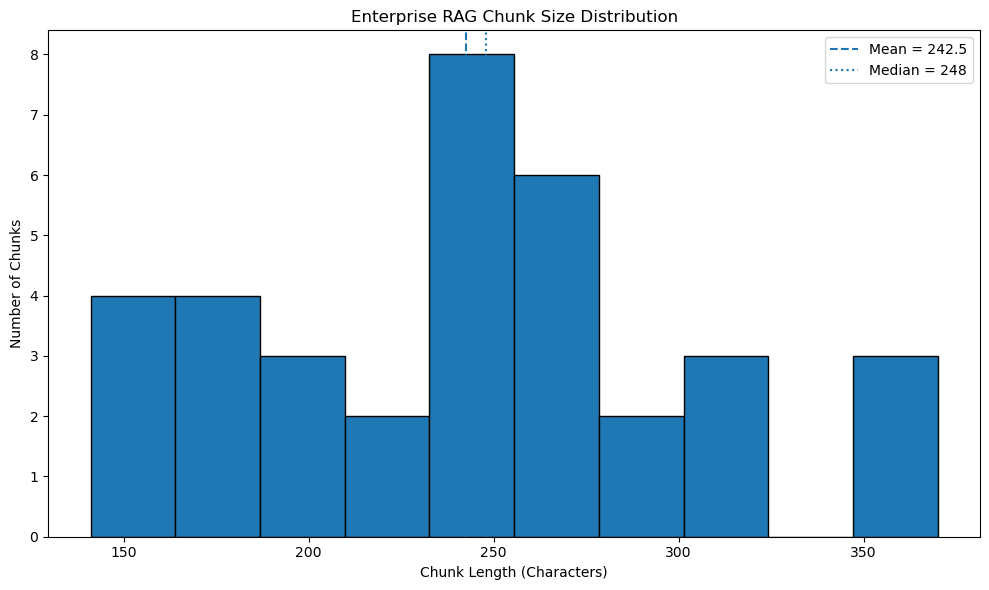

Saved: c:\Users\dayac\OneDrive\Desktop\Enterprise_Knowledge_Intelligence\reports\figures\chunk_character_length_distribution.png


In [6]:
import matplotlib.pyplot as plt


figure_directory = project_root / "reports" / "figures"
figure_directory.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))

plt.hist(
    character_lengths,
    bins=10,
    edgecolor="black",
)

plt.axvline(
    mean(character_lengths),
    linestyle="--",
    label=f"Mean = {mean(character_lengths):.1f}",
)

plt.axvline(
    median(character_lengths),
    linestyle=":",
    label=f"Median = {median(character_lengths):.0f}",
)

plt.xlabel("Chunk Length (Characters)")
plt.ylabel("Number of Chunks")
plt.title("Enterprise RAG Chunk Size Distribution")

plt.legend()
plt.tight_layout()

output_path = (
    figure_directory
    / "chunk_character_length_distribution.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {output_path}")

In [7]:
from collections import defaultdict


chunk_lengths_by_document = defaultdict(list)

for chunk in chunks:
    chunk_lengths_by_document[chunk.document_id].append(
        len(chunk.content)
    )

for document_id, lengths in chunk_lengths_by_document.items():
    print(
        f"{document_id}: "
        f"chunks={len(lengths)}, "
        f"min={min(lengths)}, "
        f"max={max(lengths)}, "
        f"mean={mean(lengths):.2f}"
    )

LEG-POL-001: chunks=7, min=153, max=307, mean=250.57
HR-POL-001: chunks=7, min=145, max=351, mean=248.86
SEC-POL-001: chunks=7, min=167, max=370, mean=276.71
IT-POL-001: chunks=7, min=178, max=264, mean=223.43
FIN-POL-001: chunks=7, min=141, max=250, mean=212.71


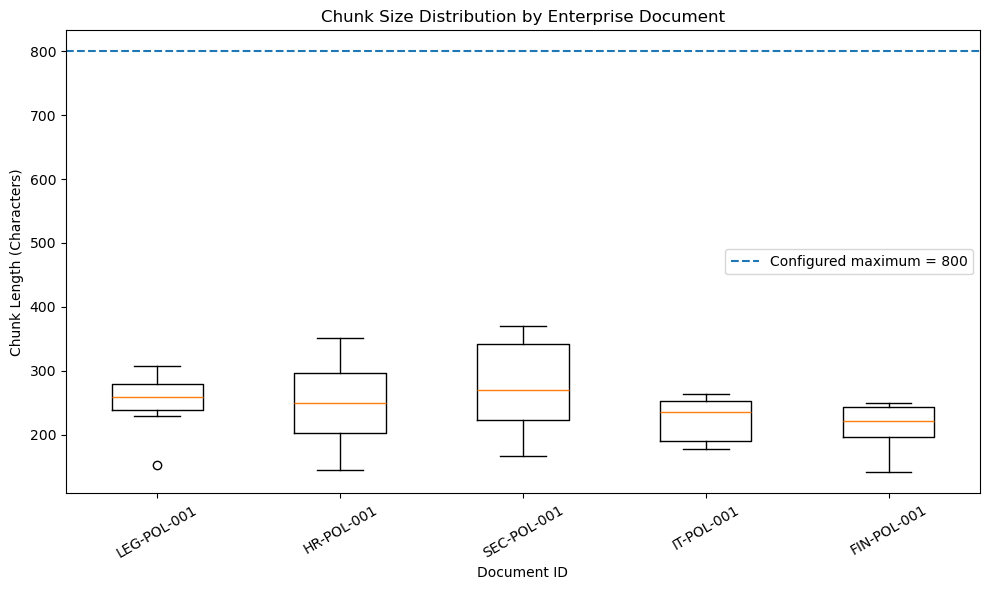

Saved: c:\Users\dayac\OneDrive\Desktop\Enterprise_Knowledge_Intelligence\reports\figures\chunk_length_by_document.png


In [8]:
document_ids = list(chunk_lengths_by_document.keys())

length_groups = [
    chunk_lengths_by_document[document_id]
    for document_id in document_ids
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    length_groups,
    tick_labels=document_ids,
)

plt.axhline(
    800,
    linestyle="--",
    label="Configured maximum = 800",
)

plt.xlabel("Document ID")
plt.ylabel("Chunk Length (Characters)")
plt.title("Chunk Size Distribution by Enterprise Document")

plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()

output_path = (
    figure_directory
    / "chunk_length_by_document.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {output_path}")